# 🌍 World Happiness 2020 — What Really Drives National Happiness?

### Independent Data Analysis Portfolio Project

This project analyzes the **World Happiness Report 2020** dataset (country averages for **2017–2019**) to investigate the factors associated with national happiness, compare regions, identify unusual country profiles, and examine the Palestinian Territories relative to the Middle East and North Africa (MENA).

> **Important:** This is an observational analysis of country-level data. Associations and correlations do not establish causation.

## 🎯 Research Questions

1. Which socioeconomic and social factors are most strongly associated with happiness?
2. How does average happiness differ across world regions?
3. Are countries with higher GDP necessarily happier?
4. Which countries are unusual relative to the global GDP–happiness pattern?
5. How does Palestine compare with the MENA regional average?

## 📦 Dataset

**Source:** [World Happiness Report 2020](https://files.worldhappiness.report/WHR20.pdf) (Helliwell, Layard, Sachs & De Neve, eds.; Sustainable Development Solutions Network), Figure 2.1 data file `WHR20_DataForFigure2.1.csv`, based on the Gallup World Poll (data downloads: [worldhappiness.report](https://worldhappiness.report/)). Each country's values are **averages over 2017–2019**, so they describe the period *before* the COVID-19 pandemic.

The file contains **153 countries and 20 variables**. The variables used in this analysis:

| Variable | Description |
|---|---|
| `Country name` | Country or territory |
| `Regional indicator` | Region group used by the report (10 regions) |
| `Ladder score` | **Happiness (the outcome).** National average answer to the Cantril ladder question: 0 = worst possible life, 10 = best possible life |
| `Logged GDP per capita` | Log of GDP per capita (purchasing-power adjusted) |
| `Social support` | Share answering "yes" to: *if you were in trouble, do you have relatives or friends you can count on?* |
| `Healthy life expectancy` | Healthy life expectancy at birth, in years (WHO data) |
| `Freedom to make life choices` | Share satisfied with their freedom to choose what to do with their life |
| `Generosity` | Share who donated to charity in the past month, **after removing the effect of GDP per capita** (a regression residual, so it can be negative) |
| `Perceptions of corruption` | Average share saying corruption is widespread in government and in business (higher = more perceived corruption) |

The remaining columns (standard error, confidence-interval whiskers, the `Explained by: …` contributions and `Dystopia + residual`) come from the report's own statistical model. They are checked in Section 3 but **not used as predictors**.

## 1. Setup

Imports, the random seed and the visual theme live in one cell, so the notebook runs top to bottom with a consistent look.

In [1]:
import platform
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42

# ---- One visual theme for the whole notebook (change colours here only) ----
BG, FG, GRID = "#010A19", "#EEF2F7", "#33405C"
TEAL, PURPLE, CORAL, AMBER = "#60F5D2", "#D6B2FC", "#FF7A90", "#F6E27F"

sns.set_theme(
    style="dark",
    context="notebook",
    rc={
        "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
        "axes.edgecolor": GRID, "axes.labelcolor": FG, "axes.titlecolor": FG,
        "axes.titlesize": 14, "axes.titleweight": "bold",
        "axes.grid": True, "axes.axisbelow": True,
        "grid.color": GRID, "grid.linewidth": 0.7,
        "text.color": FG, "xtick.color": FG, "ytick.color": FG,
        "legend.facecolor": BG, "legend.edgecolor": GRID, "legend.labelcolor": FG,
    },
)
sns.set_palette([TEAL, PURPLE, AMBER, CORAL, "#7AA2FF", "#8BE28B", "#FFB86B", "#4DD0E1", "#C792EA", "#FF9E80"])

REGION_COLORS = {  # one clearly distinguishable colour per region
    "North America and ANZ": TEAL,
    "Western Europe": PURPLE,
    "Latin America and Caribbean": AMBER,
    "Central and Eastern Europe": CORAL,
    "East Asia": "#5B9DFF",
    "Commonwealth of Independent States": "#7CE070",
    "Southeast Asia": "#FF9F43",
    "Middle East and North Africa": "#FFFFFF",
    "South Asia": "#9AA5B8",
    "Sub-Saharan Africa": "#E056FD",
}

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

IMG_DIR = Path("images")
IMG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    """Save a figure to images/ so the README can reuse it."""
    fig.savefig(IMG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 2. Load the Data

The CSV lives in `data/` (see the README for the source). Run the notebook from the repository root.

In [2]:
DATA_PATH = Path("data/WHR20_DataForFigure2.1.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run this notebook from the repository root "
        "(see the README, section 'Data')."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 153 rows × 20 columns


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.809,0.031,7.870,7.748,10.639,0.954,71.901,0.949,-0.059,0.195,1.972,1.285,1.500,0.961,0.662,0.160,0.478,2.763
1,Denmark,Western Europe,7.646,0.033,7.711,7.580,10.774,0.956,72.403,0.951,0.066,0.168,1.972,1.327,1.503,0.979,0.665,0.243,0.495,2.433
2,Switzerland,Western Europe,7.560,0.035,7.629,7.491,10.980,0.943,74.102,0.921,0.106,0.304,1.972,1.391,1.472,1.041,0.629,0.269,0.408,2.350
3,Iceland,Western Europe,7.504,0.060,7.621,7.388,10.773,0.975,73.000,0.949,0.247,0.712,1.972,1.327,1.548,1.001,0.662,0.362,0.145,2.461
4,Norway,Western Europe,7.488,0.035,7.556,7.420,11.088,0.952,73.201,0.956,0.135,0.263,1.972,1.424,1.495,1.008,0.670,0.288,0.434,2.168


## 3. Data Quality Assessment

Before analyzing relationships, inspect:

- Data types
- Missing values
- Duplicate rows
- Unique countries
- Numeric ranges
- Whether any columns are components of the outcome itself (which would make them unusable as predictors)

In [3]:
print("Data types and non-null counts:")
df.info()

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
    "unique": df.nunique(),
}).sort_values("missing_%", ascending=False, kind="stable")

display(quality)

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate country names: {df['Country name'].duplicated().sum()}")

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                153 non-null    str    
 1   Regional indicator                          153 non-null    str    
 2   Ladder score                                153 non-null    float64
 3   Standard error of ladder score              153 non-null    float64
 4   upperwhisker                                153 non-null    float64
 5   lowerwhisker                                153 non-null    float64
 6   Logged GDP per capita                       153 non-null    float64
 7   Social support                              153 non-null    float64
 8   Healthy life expectancy                     153 non-null    float64
 9   Freedom to make life choices                153 non-null    float6

,dtype,missing,missing_%,unique
Country name,str,0,0.000,153
Regional indicator,str,0,0.000,10
Ladder score,float64,0,0.000,153
Standard error of ladder score,float64,0,0.000,153
upperwhisker,float64,0,0.000,153
lowerwhisker,float64,0,0.000,153
Logged GDP per capita,float64,0,0.000,152
Social support,float64,0,0.000,153
Healthy life expectancy,float64,0,0.000,152
Freedom to make life choices,float64,0,0.000,153



Duplicate rows: 0
Duplicate country names: 0


In [4]:
explained_cols = [c for c in df.columns if c.startswith("Explained by")] + ["Dystopia + residual"]
component_gap = (df[explained_cols].sum(axis=1) - df["Ladder score"]).abs().max()
se = df["Standard error of ladder score"]

assert df["Ladder score"].between(0, 10).all(), "Ladder scores should lie on the 0-10 scale"

print(f"Ladder scores: {df['Ladder score'].min():.2f} to {df['Ladder score'].max():.2f} (0-10 scale)")
print(f"Largest gap between the ladder score and the sum of its 7 model components: {component_gap:.5f}")
print(f"Standard error of the ladder score: {se.min():.3f} to {se.max():.3f} (median {se.median():.3f})")

Ladder scores: 2.57 to 7.81 (0-10 scale)
Largest gap between the ladder score and the sum of its 7 model components: 0.00005
Standard error of the ladder score: 0.026 to 0.121 (median 0.051)


### Takeaways

- The data is complete: **no missing values, no duplicate rows, no duplicate countries**.
- The seven `Explained by: …` / `Dystopia + residual` columns **add up to the ladder score** (largest gap ≈ 0.00005). They are components of the outcome produced by the report's own model, so using them as predictors would be circular. They are excluded.
- Ladder scores are survey averages with standard errors of roughly 0.03–0.12 (median 0.05), so very small differences between neighbouring countries are not meaningful.

## 4. Data Preparation

Shorter, consistent column names make the analysis easier to read. Only the columns used in the analysis are kept, and `Logged GDP per capita` becomes `log_gdp` so the name says what it is.

In [5]:
df = df.rename(columns={
    "Country name": "country",
    "Regional indicator": "region",
    "Ladder score": "happiness",
    "Logged GDP per capita": "log_gdp",
    "Social support": "social_support",
    "Healthy life expectancy": "life_expectancy",
    "Freedom to make life choices": "freedom",
    "Generosity": "generosity",
    "Perceptions of corruption": "corruption",
})

FEATURES = ["log_gdp", "social_support", "life_expectancy", "freedom", "generosity", "corruption"]
ANALYSIS_COLS = ["happiness"] + FEATURES

LABELS = {  # readable names for charts
    "happiness": "Happiness (ladder score)",
    "log_gdp": "Log GDP per capita",
    "social_support": "Social support",
    "life_expectancy": "Healthy life expectancy",
    "freedom": "Freedom to make life choices",
    "generosity": "Generosity",
    "corruption": "Perceived corruption (higher = worse)",
}

df = df[["country", "region"] + ANALYSIS_COLS].copy()

assert df[ANALYSIS_COLS].notna().all().all(), "Unexpected missing values"
print(f"Analysis dataset: {df.shape[0]} countries × {df.shape[1]} columns")
display(df[ANALYSIS_COLS].describe().T)

Analysis dataset: 153 countries × 9 columns


,count,mean,std,min,25%,50%,75%,max
happiness,153.000,5.473,1.112,2.567,4.724,5.515,6.228,7.809
log_gdp,153.000,9.296,1.202,6.493,8.351,9.456,10.265,11.451
social_support,153.000,0.809,0.121,0.319,0.737,0.829,0.907,0.975
life_expectancy,153.000,64.446,7.058,45.200,58.962,66.305,69.289,76.805
freedom,153.000,0.783,0.118,0.397,0.715,0.800,0.878,0.975
generosity,153.000,-0.015,0.152,-0.301,-0.127,-0.034,0.085,0.561
corruption,153.000,0.733,0.175,0.110,0.683,0.783,0.849,0.936


## 5. Feature Engineering

Two derived columns are created:

- `happiness_rank`: global ranking by happiness score (1 = happiest).
- `gdp_quartile`: four equal-sized groups of countries by logged GDP per capita (used in Section 9).

In [6]:
df["happiness_rank"] = df["happiness"].rank(ascending=False, method="min").astype(int)

QUARTILE_LABELS = ["Low", "Lower-Middle", "Upper-Middle", "High"]
df["gdp_quartile"] = pd.qcut(df["log_gdp"], q=4, labels=QUARTILE_LABELS)

display(df[["country", "happiness", "happiness_rank", "log_gdp", "gdp_quartile"]].head(10))

print("GDP quartile boundaries (log GDP per capita):")
display(df.groupby("gdp_quartile", observed=True)["log_gdp"].agg(["min", "max", "count"]))

,country,happiness,happiness_rank,log_gdp,gdp_quartile
0,Finland,7.809,1,10.639,High
1,Denmark,7.646,2,10.774,High
2,Switzerland,7.560,3,10.980,High
3,Iceland,7.504,4,10.773,High
4,Norway,7.488,5,11.088,High
5,Netherlands,7.449,6,10.813,High
6,Sweden,7.353,7,10.759,High
7,New Zealand,7.300,8,10.501,High
8,Austria,7.294,9,10.743,High
9,Luxembourg,7.238,10,11.451,High


GDP quartile boundaries (log GDP per capita):


,min,max,count
gdp_quartile,,,
Low,6.493,8.351,39
Lower-Middle,8.389,9.456,38
Upper-Middle,9.500,10.265,38
High,10.340,11.451,38


## 6. Global Happiness Overview

### Top and bottom countries

In [7]:
overview_cols = ["happiness_rank", "country", "region", "happiness", "log_gdp", "life_expectancy"]

top10 = df.nlargest(10, "happiness")[overview_cols].reset_index(drop=True)
bottom10 = df.nsmallest(10, "happiness")[overview_cols].reset_index(drop=True)

print("Top 10 happiest countries")
display(top10)

print("Bottom 10 happiest countries")
display(bottom10)

Top 10 happiest countries


,happiness_rank,country,region,happiness,log_gdp,life_expectancy
0,1,Finland,Western Europe,7.809,10.639,71.901
1,2,Denmark,Western Europe,7.646,10.774,72.403
2,3,Switzerland,Western Europe,7.560,10.980,74.102
3,4,Iceland,Western Europe,7.504,10.773,73.000
4,5,Norway,Western Europe,7.488,11.088,73.201
5,6,Netherlands,Western Europe,7.449,10.813,72.301
6,7,Sweden,Western Europe,7.353,10.759,72.601
7,8,New Zealand,North America and ANZ,7.300,10.501,73.203
8,9,Austria,Western Europe,7.294,10.743,73.003
9,10,Luxembourg,Western Europe,7.238,11.451,72.600


Bottom 10 happiest countries


,happiness_rank,country,region,happiness,log_gdp,life_expectancy
0,153,Afghanistan,South Asia,2.567,7.463,52.590
1,152,South Sudan,Sub-Saharan Africa,2.817,7.425,51.000
2,151,Zimbabwe,Sub-Saharan Africa,3.299,7.866,55.617
3,150,Rwanda,Sub-Saharan Africa,3.312,7.600,61.099
4,149,Central African Republic,Sub-Saharan Africa,3.476,6.625,45.200
5,148,Tanzania,Sub-Saharan Africa,3.476,7.968,57.496
6,147,Botswana,Sub-Saharan Africa,3.479,9.711,58.924
7,146,Yemen,Middle East and North Africa,3.527,7.760,56.727
8,145,Malawi,Sub-Saharan Africa,3.538,7.062,57.593
9,144,India,South Asia,3.573,8.850,60.215


Nine of the top 10 countries are in Western Europe (the tenth is New Zealand), while seven of the bottom 10 are in Sub-Saharan Africa. Botswana is an early hint that income is not the whole story: its logged GDP (9.71) is above the world median (9.46), yet it ranks 147th of 153.

### Regional distribution

The regional comparison uses both the mean and the standard deviation so that we can distinguish overall happiness from within-region variation.

In [8]:
regional_summary = (
    df.groupby("region")
      .agg(
          countries=("country", "count"),
          mean_happiness=("happiness", "mean"),
          median_happiness=("happiness", "median"),
          std_happiness=("happiness", "std"),
          mean_log_gdp=("log_gdp", "mean"),
          mean_life_expectancy=("life_expectancy", "mean"),
      )
      .sort_values("mean_happiness", ascending=False)
)

display(regional_summary)

,countries,mean_happiness,median_happiness,std_happiness,mean_log_gdp,mean_life_expectancy
region,,,,,,
North America and ANZ,4,7.174,7.227,0.160,10.710,72.177
Western Europe,21,6.899,7.094,0.683,10.688,72.864
Latin America and Caribbean,21,5.982,6.137,0.660,9.303,66.717
Central and Eastern Europe,17,5.884,6.000,0.523,9.976,68.149
East Asia,6,5.715,5.691,0.459,10.317,71.095
Southeast Asia,9,5.383,5.353,0.657,9.367,64.710
Commonwealth of Independent States,12,5.358,5.541,0.537,9.207,64.727
Middle East and North Africa,17,5.227,5.005,0.988,9.714,65.314
South Asia,7,4.475,4.833,1.084,8.559,62.449


Average happiness differs by about **2.8 points** between the top region (North America and ANZ, 7.17) and the bottom one (Sub-Saharan Africa, 4.38). Regions also differ in internal diversity: South Asia (SD 1.08) and MENA (SD 0.99) are the most heterogeneous, while North America and ANZ (SD 0.16) is tightly clustered, although it contains only four countries.

## 7. Exploratory Data Analysis

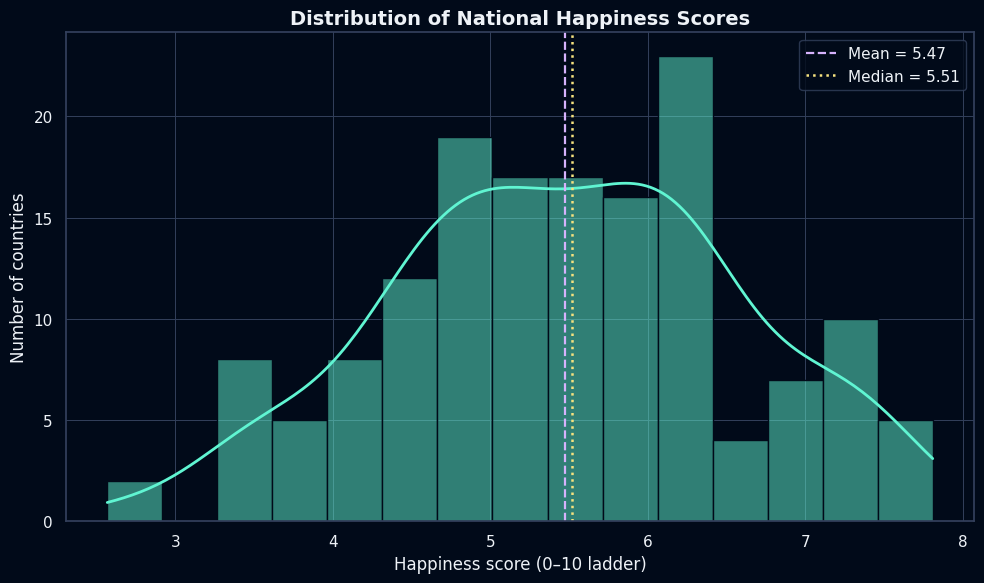

Skewness: -0.11
Lowest:  Afghanistan (2.57)
Highest: Finland (7.81)


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x="happiness", bins=15, kde=True, color=TEAL, edgecolor=BG,
             line_kws={"linewidth": 2}, ax=ax)
ax.axvline(df["happiness"].mean(), color=PURPLE, linestyle="--", linewidth=1.6,
           label=f"Mean = {df['happiness'].mean():.2f}")
ax.axvline(df["happiness"].median(), color=AMBER, linestyle=":", linewidth=1.8,
           label=f"Median = {df['happiness'].median():.2f}")

ax.set(title="Distribution of National Happiness Scores",
       xlabel="Happiness score (0–10 ladder)", ylabel="Number of countries")
ax.legend()
plt.tight_layout()
save_fig(fig, "01_happiness_distribution")
plt.show()

print(f"Skewness: {df['happiness'].skew():.2f}")
print(f"Lowest:  {df.loc[df['happiness'].idxmin(), 'country']} ({df['happiness'].min():.2f})")
print(f"Highest: {df.loc[df['happiness'].idxmax(), 'country']} ({df['happiness'].max():.2f})")

### Insight

Scores span **2.57 (Afghanistan) to 7.81 (Finland)**. The distribution is roughly symmetric (mean 5.47, median 5.51, skewness −0.11) and the middle half of all countries scores between 4.72 and 6.23. Differences between countries are a matter of degree rather than a few exceptional cases.

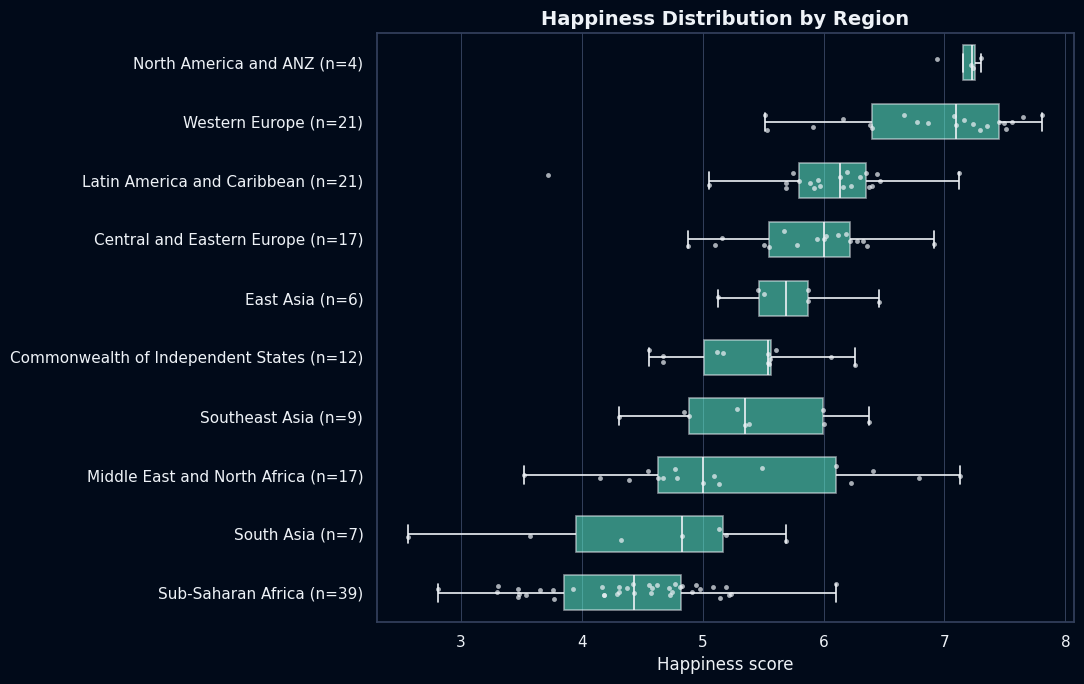

In [10]:
region_order = df.groupby("region")["happiness"].median().sort_values(ascending=False).index.tolist()
region_counts = df["region"].value_counts()

fig, ax = plt.subplots(figsize=(11, 7))

sns.boxplot(data=df, y="region", x="happiness", order=region_order, color=TEAL, saturation=1,
            linecolor=FG, linewidth=1.2, fliersize=0, width=0.6, boxprops={"alpha": 0.55}, ax=ax)
sns.stripplot(data=df, y="region", x="happiness", order=region_order, color=FG, size=3.5,
              alpha=0.7, jitter=0.15, ax=ax)

ax.set_yticks(range(len(region_order)), labels=[f"{r} (n={region_counts[r]})" for r in region_order])
ax.set(title="Happiness Distribution by Region", xlabel="Happiness score", ylabel="")
plt.tight_layout()
save_fig(fig, "02_happiness_by_region")
plt.show()

### Insight

Region matters: regional medians run from **7.23** (North America and ANZ) down to **4.43** (Sub-Saharan Africa). The wide MENA box reflects a region that contains both Israel (7.13) and Yemen (3.53). Every dot is a country, so small regions (n = 4–9) can be judged as small samples.

### GDP vs Happiness

The relationship is observational: a positive association would indicate that countries with higher logged GDP per capita tend to have higher happiness scores, but it would not prove that GDP causes happiness.

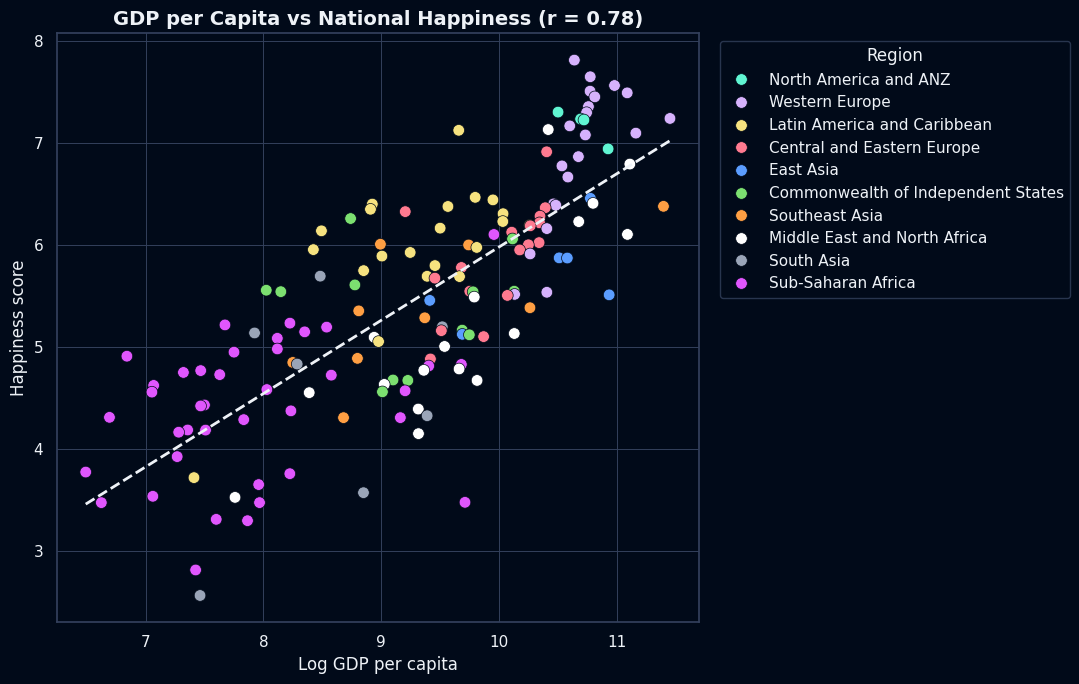

Pearson r = 0.775 | R² = 0.601 | slope = 0.72 happiness points per +1 log-GDP unit


In [11]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(data=df, x="log_gdp", y="happiness", hue="region", hue_order=region_order,
                palette=REGION_COLORS, s=70, edgecolor=BG, linewidth=0.5, ax=ax)
sns.regplot(data=df, x="log_gdp", y="happiness", scatter=False, ci=None,
            line_kws={"color": FG, "linewidth": 2, "linestyle": "--"}, ax=ax)

r = df["log_gdp"].corr(df["happiness"])
ax.set(title=f"GDP per Capita vs National Happiness (r = {r:.2f})",
       xlabel="Log GDP per capita", ylabel="Happiness score")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig(fig, "03_gdp_vs_happiness")
plt.show()

slope, intercept = np.polyfit(df["log_gdp"], df["happiness"], deg=1)
print(f"Pearson r = {r:.3f} | R² = {r**2:.3f} | slope = {slope:.2f} happiness points per +1 log-GDP unit")

### Insight

Log GDP and happiness have a Pearson correlation of **0.775 (R² = 0.60)**: income alone accounts for about 60% of the variation in national happiness. Each extra unit of logged GDP (roughly a 2.7× higher GDP per capita) goes with about **+0.72 happiness points**.

The cloud is wide, though. Botswana (log GDP 9.71, happiness 3.48) and Costa Rica (9.66, 7.12) have almost identical GDP per capita and are 3.6 points apart.

## 8. Correlation Analysis

Correlation measures the strength and direction of linear association. It should not be interpreted as evidence of causality.

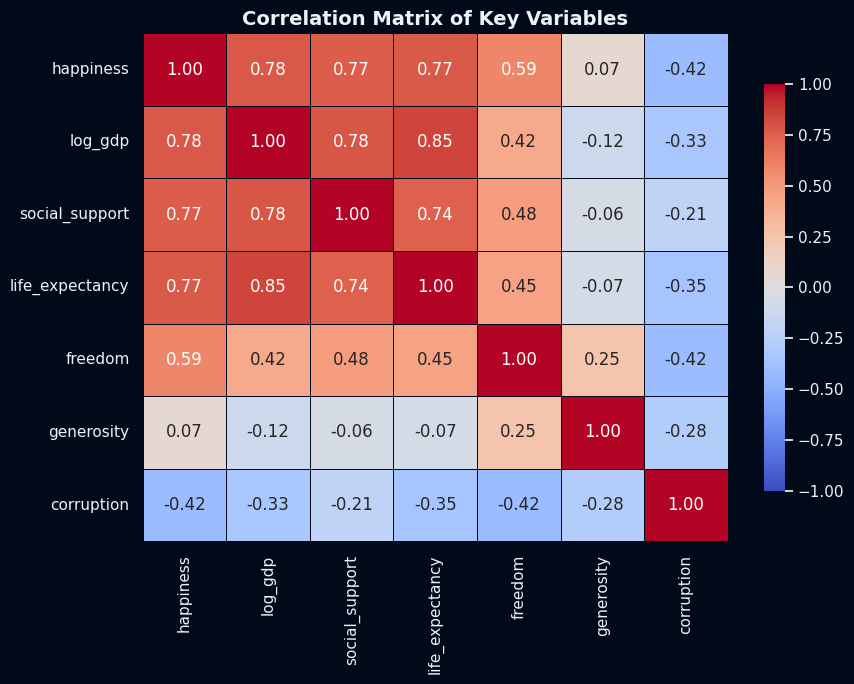

,correlation_with_happiness
log_gdp,0.775
life_expectancy,0.770
social_support,0.765
freedom,0.591
corruption,-0.418
generosity,0.069


In [12]:
corr = df[ANALYSIS_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor=BG, cbar_kws={"shrink": 0.8}, ax=ax)
ax.grid(False)
ax.set_title("Correlation Matrix of Key Variables")
plt.tight_layout()
save_fig(fig, "04_correlation_heatmap")
plt.show()

happiness_corr = corr["happiness"].drop("happiness").sort_values(key=abs, ascending=False)
display(happiness_corr.to_frame("correlation_with_happiness"))

### Interpretation

Ranked by absolute correlation, **log GDP (0.775), healthy life expectancy (0.770) and social support (0.765)** are almost tied at the top, followed by freedom (0.591) and perceived corruption (−0.418: more perceived corruption goes with lower happiness). Generosity is essentially uncorrelated (0.069), partly by construction, since it is already adjusted for GDP.

The explanatory variables are also correlated with each other, for example log GDP with life expectancy (r = 0.85) and with social support (r = 0.78). The ranking above therefore cannot say which factor "matters most"; the regression in Section 12 looks at their joint contribution.

## 9. GDP Quartile Analysis

Instead of looking only at a continuous GDP–happiness relationship, compare happiness across four GDP groups.

,mean,median,std,count,mean_change_vs_previous
gdp_quartile,,,,,
Low,4.325,4.423,0.740,39,NaN
Lower-Middle,5.203,5.145,0.726,38,0.878
Upper-Middle,5.641,5.618,0.662,38,0.438
High,6.755,6.827,0.612,38,1.114


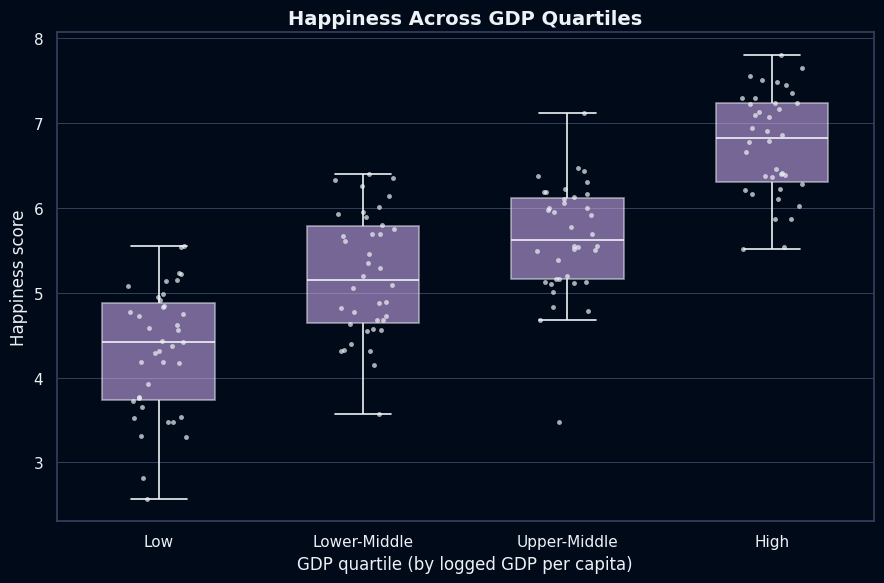

In [13]:
gdp_group_summary = (
    df.groupby("gdp_quartile", observed=True)["happiness"]
      .agg(["mean", "median", "std", "count"])
)
gdp_group_summary["mean_change_vs_previous"] = gdp_group_summary["mean"].diff()

display(gdp_group_summary)

fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(data=df, x="gdp_quartile", y="happiness", order=QUARTILE_LABELS, color=PURPLE,
            saturation=1, linecolor=FG, linewidth=1.2, fliersize=0, width=0.55,
            boxprops={"alpha": 0.55}, ax=ax)
sns.stripplot(data=df, x="gdp_quartile", y="happiness", order=QUARTILE_LABELS, color=FG,
              size=3.5, alpha=0.7, jitter=0.15, ax=ax)

ax.set(title="Happiness Across GDP Quartiles",
       xlabel="GDP quartile (by logged GDP per capita)", ylabel="Happiness score")
plt.tight_layout()
save_fig(fig, "05_gdp_quartiles")
plt.show()

### Insight

Average happiness climbs from **4.33** in the lowest GDP quartile to **6.76** in the highest, a gap of about 2.4 points. The steps are uneven: +0.88, +0.44 and then +1.11 between successive quartiles. The groups also overlap considerably (within-group SD 0.61–0.74), so the GDP group alone does not determine a country's score.

## 10. Outlier / Quadrant Analysis

A particularly interesting question is whether high GDP always corresponds to high happiness.

We classify countries using the global median of GDP and happiness ("high" means at or above the world median):

- **High GDP + High Happiness**
- **High GDP + Low Happiness**
- **Low GDP + High Happiness**
- **Low GDP + Low Happiness**

Median splits are easy to explain but crude: a country just below a line counts as a "mismatch". So the analysis also measures each country's distance from the fitted GDP–happiness line (its *residual*) to find the genuinely unusual cases.

In [14]:
gdp_median = df["log_gdp"].median()
happiness_median = df["happiness"].median()


def classify_profile(row):
    high_gdp = row["log_gdp"] >= gdp_median
    high_happiness = row["happiness"] >= happiness_median

    if high_gdp and high_happiness:
        return "High GDP / High Happiness"
    if high_gdp and not high_happiness:
        return "High GDP / Low Happiness"
    if not high_gdp and high_happiness:
        return "Low GDP / High Happiness"
    return "Low GDP / Low Happiness"


df["profile"] = df.apply(classify_profile, axis=1)

profile_counts = df["profile"].value_counts().rename("countries").to_frame()
profile_counts["share_%"] = profile_counts["countries"] / len(df) * 100
display(profile_counts)

# Print the two "mismatch" groups in full (tables truncate long lists)
for name in ["High GDP / Low Happiness", "Low GDP / High Happiness"]:
    members = df.loc[df["profile"] == name].sort_values("happiness")["country"].tolist()
    print(f"{name} ({len(members)}): {', '.join(members)}\n")

,countries,share_%
profile,,
High GDP / High Happiness,61,39.869
Low GDP / Low Happiness,60,39.216
Low GDP / High Happiness,16,10.458
High GDP / Low Happiness,16,10.458


High GDP / Low Happiness (16): Botswana, Iran, Iraq, Gabon, Algeria, Bulgaria, Turkmenistan, China, Turkey, Macedonia, Azerbaijan, Maldives, Malaysia, Libya, Croatia, Hong Kong S.A.R. of China

Low GDP / High Happiness (16): Kyrgyzstan, Tajikistan, Moldova, Bosnia and Herzegovina, Paraguay, Pakistan, Bolivia, Jamaica, Ecuador, Honduras, Philippines, Nicaragua, Uzbekistan, Kosovo, El Salvador, Guatemala



In [15]:
# Residual = actual happiness minus the happiness predicted from GDP alone
slope, intercept = np.polyfit(df["log_gdp"], df["happiness"], deg=1)
df["gdp_residual"] = df["happiness"] - (intercept + slope * df["log_gdp"])

residual_cols = ["country", "region", "happiness", "log_gdp", "gdp_residual"]

print(f"Residual SD across countries: {df['gdp_residual'].std():.2f} happiness points\n")

print("Happier than their GDP predicts")
display(df.nlargest(6, "gdp_residual")[residual_cols].reset_index(drop=True))

print("Less happy than their GDP predicts")
display(df.nsmallest(6, "gdp_residual")[residual_cols].reset_index(drop=True))

Residual SD across countries: 0.70 happiness points

Happier than their GDP predicts


,country,region,happiness,log_gdp,gdp_residual
0,Costa Rica,Latin America and Caribbean,7.121,9.658,1.388
1,Finland,Western Europe,7.809,10.639,1.371
2,Nicaragua,Latin America and Caribbean,6.137,8.493,1.240
3,Niger,Sub-Saharan Africa,4.910,6.842,1.197
4,Guatemala,Latin America and Caribbean,6.399,8.925,1.192
5,Uzbekistan,Commonwealth of Independent States,6.258,8.740,1.183


Less happy than their GDP predicts


,country,region,happiness,log_gdp,gdp_residual
0,Botswana,Sub-Saharan Africa,3.479,9.711,-2.293
1,Afghanistan,South Asia,2.567,7.463,-1.591
2,India,South Asia,3.573,8.850,-1.580
3,Egypt,Middle East and North Africa,4.151,9.317,-1.337
4,South Sudan,Sub-Saharan Africa,2.817,7.425,-1.314
5,Sri Lanka,South Asia,4.327,9.390,-1.214


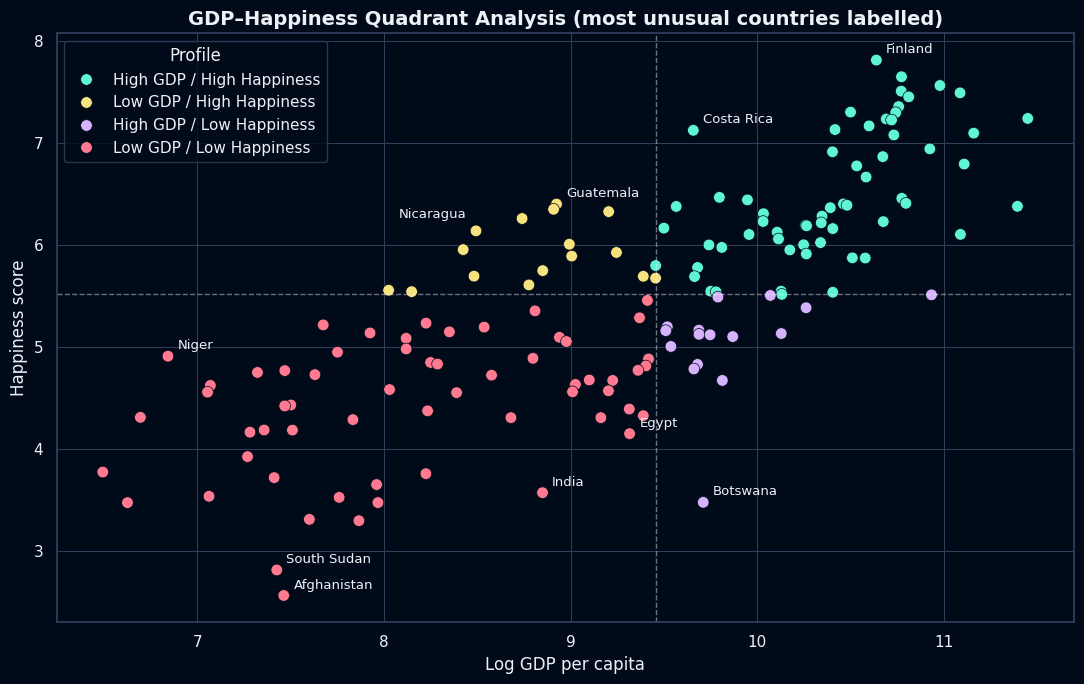

In [16]:
PROFILE_COLORS = {
    "High GDP / High Happiness": TEAL,
    "Low GDP / High Happiness": AMBER,
    "High GDP / Low Happiness": PURPLE,
    "Low GDP / Low Happiness": CORAL,
}

fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(data=df, x="log_gdp", y="happiness", hue="profile", hue_order=list(PROFILE_COLORS),
                palette=PROFILE_COLORS, s=70, edgecolor=BG, linewidth=0.5, ax=ax)

ax.axvline(gdp_median, linestyle="--", linewidth=1, color=FG, alpha=0.45)
ax.axhline(happiness_median, linestyle="--", linewidth=1, color=FG, alpha=0.45)

# Label the most unusual countries (largest residuals in either direction)
outliers = pd.concat([df.nlargest(5, "gdp_residual"), df.nsmallest(5, "gdp_residual")])
LABEL_OFFSETS = {"Nicaragua": (-7, 9)}  # nudge labels that would run into neighbouring points
for _, row in outliers.iterrows():
    dx, dy = LABEL_OFFSETS.get(row["country"], (7, 5))
    ax.annotate(row["country"], (row["log_gdp"], row["happiness"]), xytext=(dx, dy),
                textcoords="offset points", fontsize=9.5, color=FG, ha="right" if dx < 0 else "left")

ax.set(title="GDP–Happiness Quadrant Analysis (most unusual countries labelled)",
       xlabel="Log GDP per capita", ylabel="Happiness score")
ax.legend(title="Profile", loc="upper left")
plt.tight_layout()
save_fig(fig, "06_gdp_happiness_quadrants")
plt.show()

### Key analytical question

Countries in the **High GDP / Low Happiness** group are especially useful for testing the idea that economic resources alone explain national happiness. Their existence would indicate that other social, health, institutional, or cultural factors are also relevant.

### Insight

- **121 of 153 countries (79%)** fall in the two "expected" quadrants (High/High: 61, Low/Low: 60).
- **32 countries (21%)** are mismatches: 16 with high GDP but below-median happiness (e.g. Botswana, Iran, Iraq, Algeria, Turkey, China) and 16 with low GDP but above-median happiness (e.g. Kyrgyzstan, Pakistan, Bolivia, Guatemala, El Salvador).
- Measured against the fitted line (residual SD = 0.70), the countries **happier than their GDP predicts** are Costa Rica (+1.39), Finland (+1.37), Nicaragua (+1.24), Niger (+1.20) and Guatemala (+1.19). The ones **least happy relative to their GDP** are Botswana (−2.29), Afghanistan (−1.59), India (−1.58), Egypt (−1.34) and South Sudan (−1.31).
- Three of the five largest positive residuals are Latin American countries, and Finland, the happiest country overall, also sits far above the GDP line, so income alone does not explain the top of the ranking either.

## 11. 🇵🇸 Palestine vs MENA

Compare the Palestinian Territories (listed in the dataset as *Palestinian Territories*) with the MENA region. Palestine is itself one of the 17 MENA countries in the dataset, so the reference group **excludes** it (16 countries); otherwise the comparison would partly compare Palestine with itself.

In [17]:
PAL = "Palestinian Territories"
MENA = "Middle East and North Africa"
COMPARISON_COLS = ["happiness", "log_gdp", "life_expectancy", "social_support", "freedom", "generosity", "corruption"]

palestine = df.loc[df["country"] == PAL].iloc[0]
mena = df.loc[df["region"] == MENA]
mena_others = mena.loc[mena["country"] != PAL]  # reference group: MENA without Palestine itself

comparison = pd.DataFrame({
    "Palestine": palestine[COMPARISON_COLS].astype(float),
    "MENA average (excl. Palestine)": mena_others[COMPARISON_COLS].mean(),
})
comparison["Difference"] = comparison["Palestine"] - comparison["MENA average (excl. Palestine)"]
comparison["Rank in MENA (1 = highest value)"] = (
    mena[COMPARISON_COLS].rank(ascending=False, method="min")
    .loc[mena["country"] == PAL].iloc[0].astype(int)
)

display(comparison)

print(f"Global happiness rank: {palestine['happiness_rank']} of {len(df)}")
print(f"MENA countries in the dataset: {len(mena)} (reference group without Palestine: {len(mena_others)})")
print(f"Distance from the global GDP–happiness line: {palestine['gdp_residual']:+.2f} points "
      f"(residual SD across countries = {df['gdp_residual'].std():.2f})")

,Palestine,MENA average (excl. Palestine),Difference,Rank in MENA (1 = highest value)
happiness,4.553,5.269,-0.717,14
log_gdp,8.389,9.796,-1.407,16
life_expectancy,62.250,65.505,-3.255,14
social_support,0.825,0.795,0.030,8
freedom,0.646,0.714,-0.068,11
generosity,-0.162,-0.080,-0.083,11
corruption,0.824,0.758,0.067,3


Global happiness rank: 125 of 153
MENA countries in the dataset: 17 (reference group without Palestine: 16)
Distance from the global GDP–happiness line: -0.27 points (residual SD across countries = 0.70)


,Palestine,MENA average (excl. Palestine)
Happiness (ladder score),-0.828,-0.183
Log GDP per capita,-0.754,0.417
Healthy life expectancy,-0.311,0.150
Social support,0.136,-0.114
Freedom to make life choices,-1.168,-0.587
Generosity,-0.972,-0.428
Perceived corruption (higher = worse),0.520,0.140


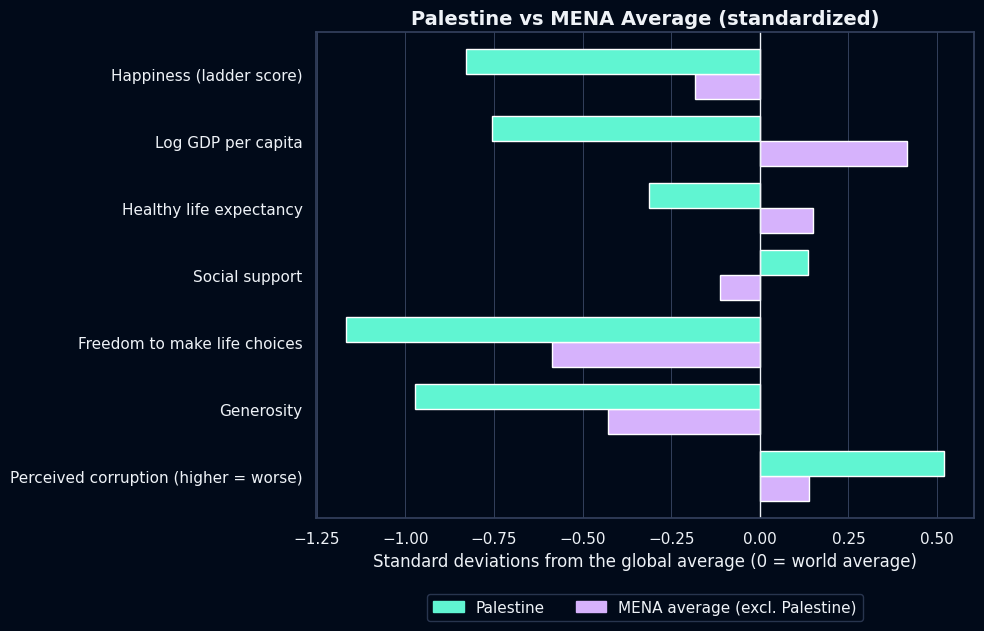

In [18]:
# Put every metric on the same scale: standard deviations from the global average
z_scores = (df[COMPARISON_COLS] - df[COMPARISON_COLS].mean()) / df[COMPARISON_COLS].std()

z_plot = pd.DataFrame({
    "Palestine": z_scores.loc[df["country"] == PAL].iloc[0],
    "MENA average (excl. Palestine)": z_scores.loc[(df["region"] == MENA) & (df["country"] != PAL)].mean(),
}).rename(index=LABELS)

display(z_plot)

def plot_palestine_vs_mena(ax, legend_y=-0.14):
    """Grouped horizontal bars: first metric on top, Palestine above the MENA bar in each pair."""
    z_plot.iloc[::-1, ::-1].plot(kind="barh", ax=ax, color=[PURPLE, TEAL], width=0.75, legend=False)
    ax.axvline(0, color=FG, linewidth=1)
    ax.grid(axis="y", visible=False)
    ax.set(xlabel="Standard deviations from the global average (0 = world average)", ylabel="")
    ax.legend(handles=[Patch(color=TEAL, label="Palestine"), Patch(color=PURPLE, label="MENA average (excl. Palestine)")],
              loc="upper center", bbox_to_anchor=(0.5, legend_y), ncol=2)


fig, ax = plt.subplots(figsize=(10, 6.5))
plot_palestine_vs_mena(ax)
ax.set_title("Palestine vs MENA Average (standardized)")
plt.tight_layout()
save_fig(fig, "07_palestine_vs_mena")
plt.show()

### Interpretation

Within this 2017–2019 dataset the Palestinian Territories rank **125th of 153** in happiness (4.55) and **14th of 17** in MENA. Compared with the other 16 MENA countries:

- **Happiness:** 0.72 points below the regional average (4.55 vs 5.27).
- **Income and health:** lower logged GDP (−1.41) and lower healthy life expectancy (−3.3 years).
- **Social support:** slightly *above* the regional average (+0.03; 8th of 17).
- **Freedom and generosity:** below average (−0.07 and −0.08). In standardized terms, freedom is the largest gap from the world average (−1.17 SD).
- **Perceived corruption:** higher than average (+0.07; 3rd highest of 17, i.e. worse).
- Relative to the **global GDP–happiness line**, the score is only 0.27 points lower than its income level would predict (residual SD = 0.70), so it sits close to the worldwide pattern.

These are descriptive comparisons within a single dataset: they show *where* the gaps are, not *why* they exist. The dataset has one national-level entry for the Palestinian Territories, so it cannot show differences within them.

## 12. 📈 Multiple Linear Regression

A multivariate model tests how the six variables jointly relate to happiness.

### Model

**Happiness ~ log GDP + Social support + Life expectancy + Freedom + Generosity + Corruption**

Design choices:

- **Standardized predictors** (mean 0, SD 1), so coefficients are comparable: each one is the change in happiness (in points) for a +1 SD difference in that variable, holding the others fixed. Raw coefficients would be misleading because the variables have very different scales (life expectancy is in years, social support lies between 0 and 1).
- **Repeated 5-fold cross-validation** instead of a single 80/20 split: with only 153 countries, one small test set (31 countries) gives an unstable estimate.
- **Bootstrap intervals** to show how uncertain each coefficient is.

This is included as an analytical modeling exercise, not as a causal model.

### Multicollinearity check

The variance inflation factor (VIF) shows how much each predictor overlaps with the others (values above roughly 5 are a warning sign).

In [19]:
X = df[FEATURES]
y = df["happiness"]


def variance_inflation(X):
    """VIF_j = 1 / (1 - R²_j), where R²_j regresses predictor j on all the others."""
    vifs = {}
    for col in X.columns:
        others = X.drop(columns=col)
        r2 = LinearRegression().fit(others, X[col]).score(others, X[col])
        vifs[col] = 1 / (1 - r2)
    return pd.Series(vifs, name="VIF").sort_values(ascending=False)


display(variance_inflation(X).to_frame())

,VIF
log_gdp,4.562
life_expectancy,3.932
social_support,3.024
freedom,1.610
corruption,1.426
generosity,1.228


All VIFs are below 5 (log GDP 4.6, life expectancy 3.9, social support 3.0), so collinearity is moderate rather than severe. Even so, these three variables overlap enough that their *individual* coefficients will be estimated imprecisely.

### Model performance

In [20]:
model = make_pipeline(StandardScaler(), LinearRegression())

cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=SEED)
scores = cross_validate(
    model, X, y, cv=cv,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"},
)

cv_results = pd.DataFrame({
    "R²": scores["test_r2"],
    "MAE": -scores["test_mae"],
    "RMSE": -scores["test_rmse"],
})
display(cv_results.agg(["mean", "std", "min", "max"]).T)

# For comparison: what a single 80/20 split would report
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
single_split_r2 = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train).score(X_test, y_test)
print(f"One 80/20 split (random_state={SEED}, {len(X_test)} test countries): R² = {single_split_r2:.3f}")

,mean,std,min,max
R²,0.695,0.100,0.270,0.853
MAE,0.463,0.060,0.297,0.616
RMSE,0.588,0.082,0.377,0.783


One 80/20 split (random_state=42, 31 test countries): R² = 0.582


Averaged over 100 test folds (5-fold CV repeated 20 times), the model reaches **R² = 0.70** (SD 0.10), MAE = 0.46 and RMSE = 0.59 happiness points. A single 80/20 split gives 0.58, well below the CV average, and individual folds range from 0.27 to 0.85. That spread is why one small test set is a shaky basis for a headline number.

### Coefficients

The final model is fitted on all 153 countries. Intervals come from 2,000 bootstrap resamples of the countries.

In-sample R² (fitted on all 153 countries): 0.748


,std_coefficient,ci_2.5%,ci_97.5%,ci_includes_zero
social_support,0.330,0.127,0.528,False
log_gdp,0.274,0.073,0.456,False
life_expectancy,0.248,0.058,0.437,False
freedom,0.209,0.102,0.320,False
corruption,-0.110,-0.232,0.018,True
generosity,0.062,-0.049,0.180,True


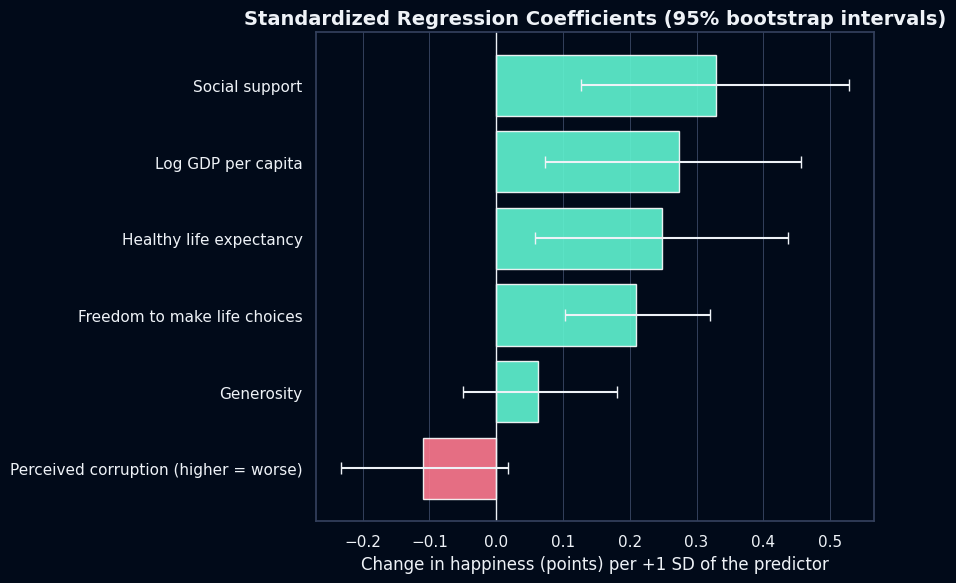

In [21]:
model.fit(X, y)
std_coefs = pd.Series(model[-1].coef_, index=FEATURES)
print(f"In-sample R² (fitted on all {len(df)} countries): {model.score(X, y):.3f}")

# Bootstrap: refit on 2,000 resamples of the countries (standardized predictors, OLS)
rng = np.random.default_rng(SEED)
X_std = ((X - X.mean()) / X.std(ddof=0)).to_numpy()
y_arr = y.to_numpy()

n_boot = 2000
boot = np.empty((n_boot, len(FEATURES)))
for b in range(n_boot):
    idx = rng.integers(0, len(y_arr), size=len(y_arr))
    design = np.column_stack([np.ones(len(idx)), X_std[idx]])
    boot[b] = np.linalg.lstsq(design, y_arr[idx], rcond=None)[0][1:]

ci_low, ci_high = np.percentile(boot, [2.5, 97.5], axis=0)

coef_table = pd.DataFrame(
    {"std_coefficient": std_coefs, "ci_2.5%": ci_low, "ci_97.5%": ci_high}
).sort_values("std_coefficient", key=abs, ascending=False)
coef_table["ci_includes_zero"] = (coef_table["ci_2.5%"] < 0) & (coef_table["ci_97.5%"] > 0)

display(coef_table)

plot_df = coef_table.sort_values("std_coefficient")
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh([LABELS[f] for f in plot_df.index], plot_df["std_coefficient"],
        color=[TEAL if v > 0 else CORAL for v in plot_df["std_coefficient"]], alpha=0.9)
ax.errorbar(plot_df["std_coefficient"], range(len(plot_df)),
            xerr=[plot_df["std_coefficient"] - plot_df["ci_2.5%"], plot_df["ci_97.5%"] - plot_df["std_coefficient"]],
            fmt="none", ecolor=FG, capsize=4, linewidth=1.5)
ax.axvline(0, color=FG, linewidth=1)

ax.set(title="Standardized Regression Coefficients (95% bootstrap intervals)",
       xlabel="Change in happiness (points) per +1 SD of the predictor", ylabel="")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "08_regression_coefficients")
plt.show()

### Reading the coefficients

- **Social support** (+0.33), **log GDP** (+0.27), **healthy life expectancy** (+0.25) and **freedom** (+0.21) all have 95% intervals that exclude zero: each keeps an independent association with happiness.
- **Perceived corruption** (−0.11) and **generosity** (+0.06) have intervals that include zero, so once the other variables are accounted for there is no clear evidence of an independent association.
- The intervals for the top three overlap heavily, so the *order* among social support, GDP and life expectancy is not reliable. What the model supports is that several related conditions contribute together.

### ⚠️ Modeling caveat

The coefficients describe the model's fitted associations under this specification. They should **not** be interpreted as causal effects. The dataset represents countries at one point in time (a 2017–2019 average), so it cannot establish temporal direction or causality.

## 13. 🎛️ Executive Dashboard

The dashboard summarizes the most important patterns rather than simply displaying every available chart.

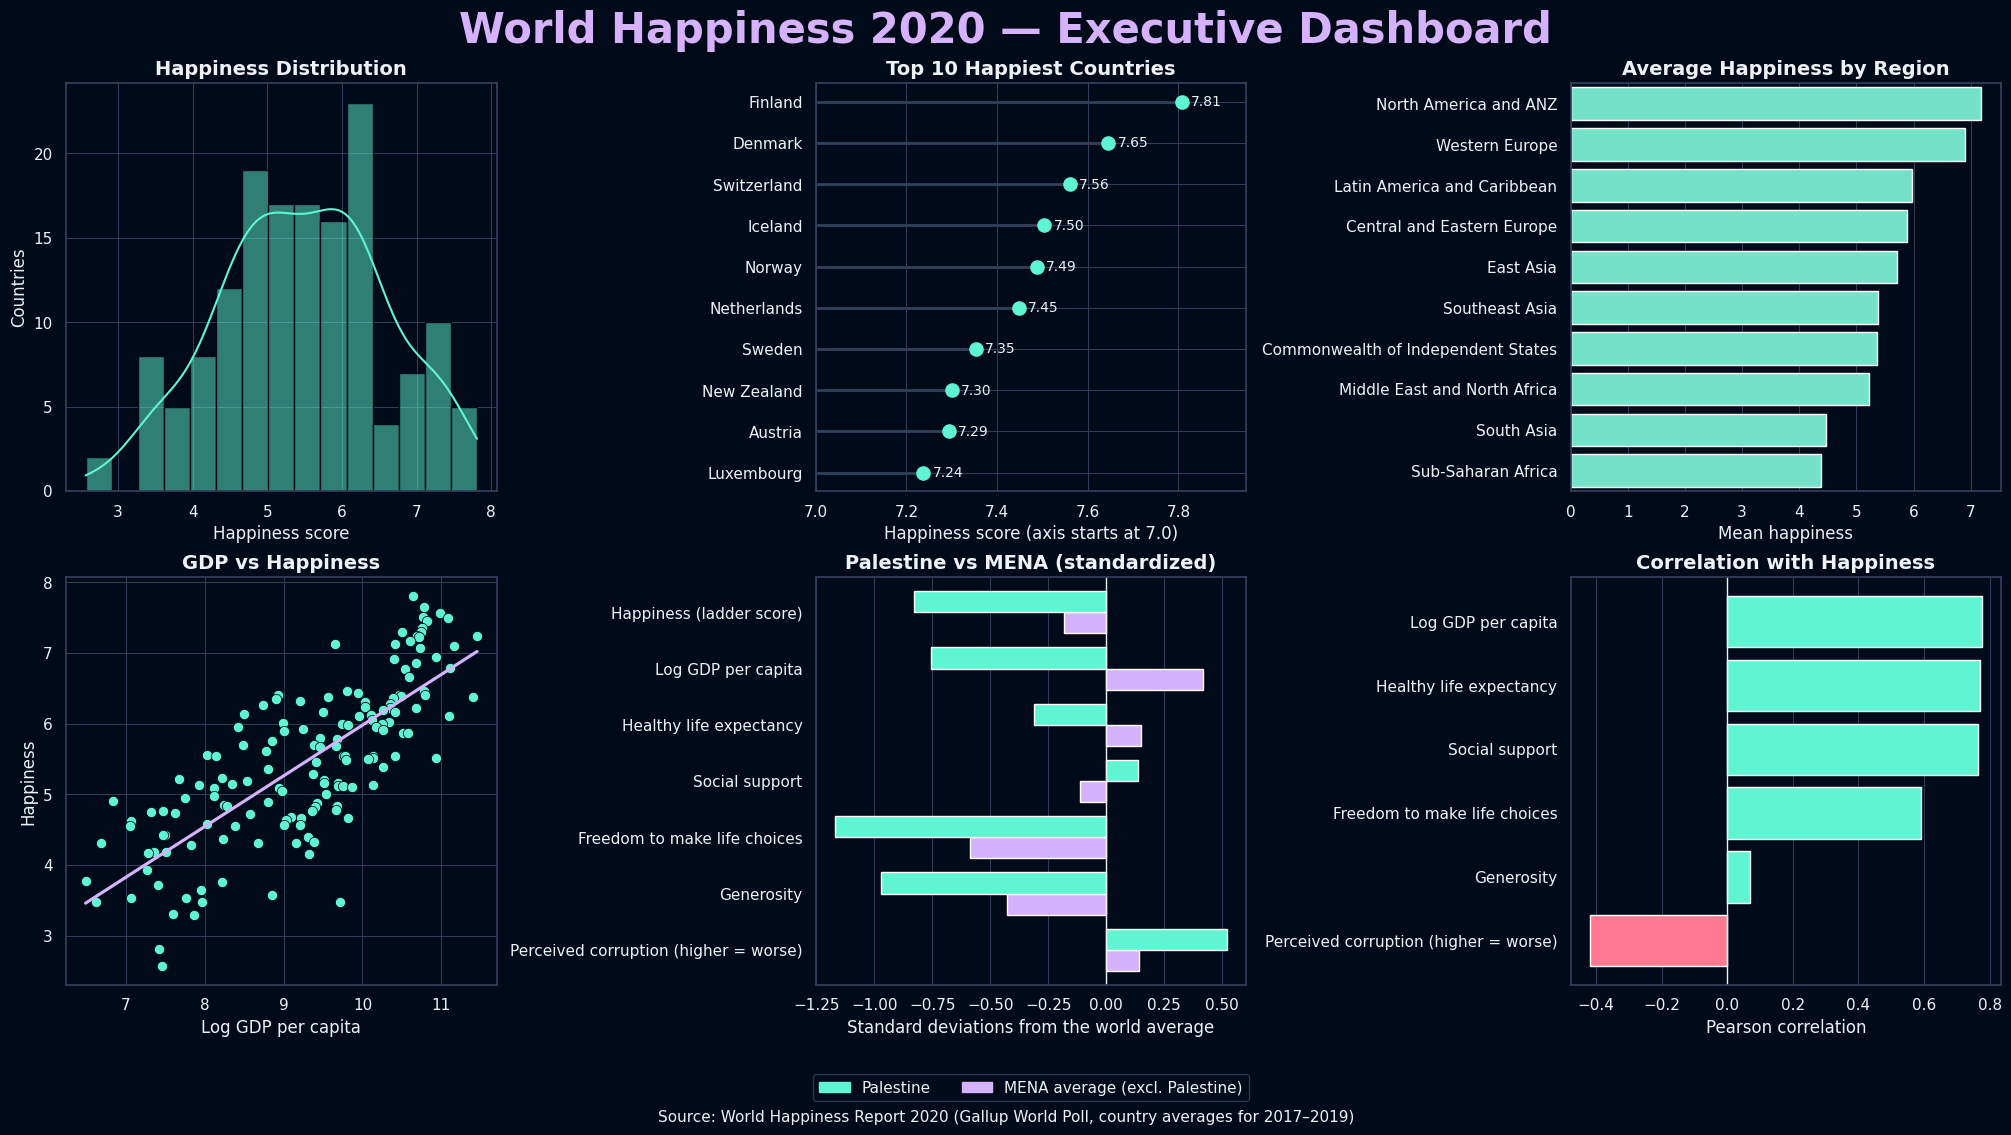

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)

# 1. Happiness distribution
sns.histplot(data=df, x="happiness", bins=15, kde=True, color=TEAL, edgecolor=BG, ax=axes[0, 0])
axes[0, 0].set(title="Happiness Distribution", xlabel="Happiness score", ylabel="Countries")

# 2. Top 10 countries: a dot plot, because the scores are so close that bars would all look identical
top10_plot = df.nlargest(10, "happiness")
y_pos = np.arange(len(top10_plot))
ax = axes[0, 1]
ax.hlines(y_pos, xmin=7.0, xmax=top10_plot["happiness"], color=GRID, linewidth=2)
ax.scatter(top10_plot["happiness"], y_pos, color=TEAL, s=90, zorder=3)
for x_val, y_val in zip(top10_plot["happiness"], y_pos):
    ax.text(x_val + 0.02, y_val, f"{x_val:.2f}", va="center", fontsize=10, color=FG)
ax.set_yticks(y_pos, labels=top10_plot["country"])
ax.invert_yaxis()
ax.set_xlim(7.0, 7.95)
ax.set(title="Top 10 Happiest Countries", xlabel="Happiness score (axis starts at 7.0)")

# 3. Regional averages (highest on top)
region_means = df.groupby("region")["happiness"].mean().sort_values(ascending=False)
sns.barplot(x=region_means.values, y=region_means.index, color=TEAL, ax=axes[0, 2])
axes[0, 2].set(title="Average Happiness by Region", xlabel="Mean happiness", ylabel="")

# 4. GDP vs happiness
sns.scatterplot(data=df, x="log_gdp", y="happiness", color=TEAL, s=55, edgecolor=BG, ax=axes[1, 0])
sns.regplot(data=df, x="log_gdp", y="happiness", scatter=False, ci=None, color=PURPLE, ax=axes[1, 0])
axes[1, 0].set(title="GDP vs Happiness", xlabel="Log GDP per capita", ylabel="Happiness")

# 5. Palestine vs MENA (standardized so every metric is visible)
plot_palestine_vs_mena(axes[1, 1], legend_y=-0.2)
axes[1, 1].set(title="Palestine vs MENA (standardized)", xlabel="Standard deviations from the world average")

# 6. Correlations with happiness
corr_plot = happiness_corr.sort_values(ascending=False)
axes[1, 2].barh([LABELS[c] for c in corr_plot.index], corr_plot.values,
                color=[TEAL if v > 0 else CORAL for v in corr_plot.values])
axes[1, 2].invert_yaxis()
axes[1, 2].axvline(0, color=FG, linewidth=1)
axes[1, 2].set(title="Correlation with Happiness", xlabel="Pearson correlation")
axes[1, 2].grid(axis="y", visible=False)

fig.suptitle("World Happiness 2020 — Executive Dashboard", fontsize=30, fontweight="bold", color=PURPLE)
fig.text(0.5, -0.015, "Source: World Happiness Report 2020 (Gallup World Poll, country averages for 2017–2019)",
         ha="center", fontsize=11, color=FG)

save_fig(fig, "09_executive_dashboard")
plt.show()

## 14. 💡 Key Findings

1. **Strongest associations:** log GDP (r = 0.775), healthy life expectancy (0.770) and social support (0.765) are almost tied as the strongest correlates of happiness, followed by freedom (0.591) and perceived corruption (−0.418). Generosity is essentially uncorrelated (0.069).
2. **Economic relationship:** GDP matters a lot but is not the whole story. Log GDP alone explains about 60% of the variation (R² = 0.60) and the top GDP quartile averages 2.4 points more than the bottom one (6.76 vs 4.33). Yet 32 of 153 countries (21%) are "mismatches", and the biggest gaps are large: Botswana sits 2.3 points below the GDP line and Costa Rica 1.4 above it.
3. **Regional differences:** North America and ANZ (7.17) and Western Europe (6.90) are the happiest regions; Sub-Saharan Africa (4.38) and South Asia (4.48) the least happy. MENA (5.23) is the most internally diverse region after South Asia.
4. **Palestine:** The Palestinian Territories rank 125th of 153 (4.55) and 14th of 17 in MENA, 0.72 points below the average of the other MENA countries. They are lower on income, life expectancy, freedom and generosity, slightly higher on social support and higher on perceived corruption. Relative to the global GDP–happiness pattern the gap is modest (−0.27).
5. **Modeling:** A six-variable linear model explains about 70% of the variation out of sample (5-fold CV R² = 0.70 ± 0.10, MAE ≈ 0.46 points). Social support, GDP, life expectancy and freedom each keep an independent association with happiness; generosity and perceived corruption do not once the others are included. Because the predictors overlap, their relative importance is uncertain.

> All findings describe **associations** in country-level data, not causes.

## 15. ⚠️ Limitations

- **Cross-sectional, pre-pandemic data.** Values are country averages for **2017–2019** (published in 2020), so the analysis says nothing about change over time or about the effects of COVID-19.
- **Correlation, not causation.** Reverse causality (happier societies may be more cooperative and productive) and omitted variables are both plausible.
- **Country-level (ecological) data.** Relationships between country averages do not necessarily hold for individuals within a country.
- **Equal weighting.** Every country counts once regardless of population (India and Iceland carry the same weight).
- **Measurement uncertainty.** Ladder scores are survey averages with standard errors of about 0.03–0.12 (median 0.05), so small rank differences between neighbouring countries are not meaningful. Survey questions may also be understood differently across cultures.
- **Overlapping predictors.** GDP, life expectancy and social support are strongly inter-correlated (VIF up to 4.6), so their individual coefficients are imprecise. Generosity is already adjusted for GDP by construction.
- **Small regions and single entries.** Some regions have few countries (North America and ANZ: 4), and the Palestinian Territories appear as one aggregate entry, so differences within them are invisible.

## 🏁 Conclusion

This analysis moves from data auditing and exploratory analysis to feature engineering, regional comparison, outlier analysis, correlation, and a cross-validated multivariate regression.

The central lesson is that **national happiness should not be reduced to a single economic measure**. GDP is a strong correlate (r = 0.775), yet about one country in five departs from the GDP–happiness pattern, and when income, health, social support and freedom are modelled together each keeps an independent association with happiness. That points to a bundle of economic, health and social conditions rather than income alone.

### Next Steps

- Extend the analysis to several World Happiness Report years to study change over time.
- Add region effects (for example a mixed-effects model) and robustness checks such as dropping the largest outliers or using robust regression.
- Use the report's standard errors to propagate the uncertainty in the ladder scores.
- Build an interactive version of the dashboard (Plotly or Streamlit).

### Environment

Versions used to produce the outputs above.

In [23]:
print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"matplotlib {matplotlib.__version__} | seaborn {sns.__version__} | scikit-learn {sklearn.__version__}")

Python 3.12.3 | pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.8 | seaborn 0.13.2 | scikit-learn 1.8.0
